# MERRA-2

MERRA-2 (Modern-Era Retrospective analysis for Research and Applications, Version 2) is a global gap-free atmospheric reanalysis dataset from NASA that combines models and observations to produce a consistent, gridded record of Earth’s atmosphere over time. The dataset covers the period of 1980-present with the latency of ~3 weeks after the end of a month. It has a spatial grid of ~0.5° latitude × 0.625° longitude, hourly to monthly products and is 3D atmosphere (multiple heights).

Variables include:

* Meteorology: air temperature, winds, air pressure, humidity
* Surface: fluxes, precipitation, radiation
* Aerosols: dust, sea salt, black carbon, sulfate
* Land surface: soil temperature and moisture, greenness

We will get matchups for 2 data collections:

* `M2TMNXLND`: monthly, gridded MERRA-2 land surface dataset providing soil moisture, soil temperature, snow, and land–atmosphere fluxes such as evaporation and runoff on a global grid.
* `M2T3NVASM`: 3-hour, gridded MERRA-2 dataset providing time-averaged 3D atmospheric variables (e.g., temperature, winds, humidity) on standard pressure levels.

*Note: In a virtual machine in AWS us-west-2, where NASA cloud data is, the point matchups are fast. In Colab, say, your compute is not in the same data region nor provider, and the same matchups might take 10x longer.*

## Prerequisites

The examples here use NASA EarthData and you need to have an account with EarthData. Make sure you can login.

In [ ]:
# if needed
pip install point-collocation

In [1]:
import earthaccess
earthaccess.login()

## There are many MERRA-2 collections available

Chatbots are good ways to explore what they are.

In [31]:
import earthaccess
results = earthaccess.search_datasets(
    project = 'MERRA-2',
)
print(len(results))
for item in results[0:10]:
    summary = item.summary()
    print(summary["short-name"])

104
M2_TMAX_PM25
M2C0NXASM
M2C0NXCTM
M2C0NXLND
M2I1NXASM
M2I1NXINT
M2I1NXLFO
M2I3NXGAS
M2I3NVAER
M2I3NPASM


## Get some sample points over land

We will start with a land dataset so want points over land.

In [1]:
import pandas as pd
url = (
    "https://raw.githubusercontent.com/"
    "fish-pace/point-collocation/main/"
    "examples/fixtures/points_1000.csv"
)
df_points = pd.read_csv(
    url,
    parse_dates=["time"]
)
df = df_points[
    (df_points["time"].dt.year < 2018) &
    (df_points["time"].dt.year > 2014) &
    (df_points["land"] == True)
].reset_index(drop=True)
# Force all timestamps to noon UTC to avoid "midnight overlap" issues
df["time"] = df["time"].dt.normalize() + pd.Timedelta(hours=12)
print(len(df))
df.head()

19


,lat,lon,time,land
0,-17.432469,24.018931,2015-08-22 12:00:00,True
1,-16.707673,14.478041,2016-03-24 12:00:00,True
2,-83.839933,111.134906,2015-05-06 12:00:00,True
3,65.250200,-159.513009,2017-10-29 12:00:00,True
4,28.315760,-1.839657,2016-12-14 12:00:00,True


## Let's plot the points

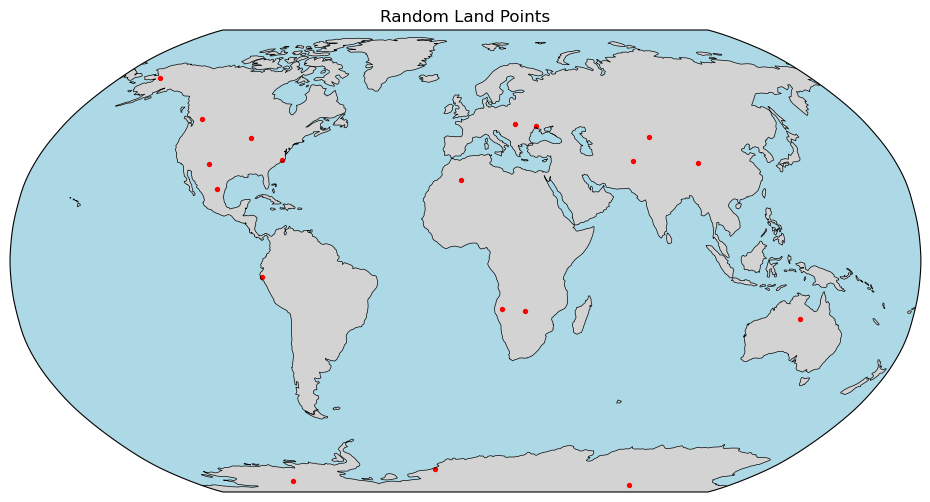

In [6]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# create Robinson projection
proj = ccrs.Robinson()

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=proj)

# add map features
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

# plot points
ax.scatter(
    df["lon"],
    df["lat"],
    s=8,
    color="red",
    transform=ccrs.PlateCarree()
)

ax.set_global()
plt.title("Random Land Points")
plt.show()

## MERRA LAND

### Create the granule plan

In [2]:
import point_collocation as pc
short_name="M2TMNXLND"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=2)

Plan: 19 points → 16 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 2 point(s):
  [0] lat=-17.4325, lon=24.0189, time=2015-08-22 12:00:00: 1 match(es)
    → https://data.gesdisc.earthdata.nasa.gov/data/MERRA2_MONTHLY/M2TMNXLND.5.12.4/2015/MERRA2_400.tavgM_2d_lnd_Nx.201508.nc4
  [1] lat=-16.7077, lon=14.4780, time=2016-03-24 12:00:00: 1 match(es)
    → https://data.gesdisc.earthdata.nasa.gov/data/MERRA2_MONTHLY/M2TMNXLND.5.12.4/2016/MERRA2_400.tavgM_2d_lnd_Nx.201603.nc4


In [3]:
# If needed we can look at the granule metadata
plan.results[0:1]

[Collection: {'ShortName': 'M2TMNXLND', 'Version': '5.12.4'}
 Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'BoundingRectangles': [{'WestBoundingCoordinate': -180.0, 'EastBoundingCoordinate': 180.0, 'NorthBoundingCoordinate': 90.0, 'SouthBoundingCoordinate': -90.0}]}}}
 Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2015-01-01T00:00:00.000Z', 'EndingDateTime': '2015-01-31T23:59:59.000Z'}}
 Size(MB): 18.402777671813965
 Data: ['https://data.gesdisc.earthdata.nasa.gov/data/MERRA2_MONTHLY/M2TMNXLND.5.12.4/2015/MERRA2_400.tavgM_2d_lnd_Nx.201501.nc4']]

## Let's plot a granule to see how it looks

There are many data variables. We will get 

* TSURF surface temperature
* GWETROOT root zone wetness
* LAI leaf area index

In [27]:
%%time
ds = plan.open_dataset(0)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',); time dim='time' (1 step(s))
Points columns used: y='lat', x='lon', time='time'
CPU times: user 10.6 s, sys: 49.9 ms, total: 10.6 s
Wall time: 10.9 s


<xarray.Dataset> Size: 83MB
Dimensions:          (time: 1, lat: 361, lon: 576)
Coordinates:
  * time             (time) datetime64[ns] 8B 2015-01-01T00:30:00
  * lat              (lat) float64 3kB -90.0 -89.5 -89.0 ... 89.0 89.5 90.0
  * lon              (lon) float64 5kB -180.0 -179.4 -178.8 ... 178.8 179.4
Data variables: (12/100)
    BASEFLOW         (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ECHANGE          (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    EVLAND           (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    EVPINTR          (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    EVPSBLN          (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    EVPSOIL          (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    ...               ...
    Var_TSOIL6       (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    Var_TSURF        (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    Var_TUNST        (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    Var_TWLAND       (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    Var_TWLT         (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    Var_WCHANGE      (time, lat, lon) float32 832kB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Mon Mar 23 22...
    Filename:                          MERRA2_400.tavgM_2d_lnd_Nx.201501.nc4
    Comment:                           GMAO filename: d5124_m2_jan10.tavg1_2d...
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    DataResolution:                    0.5 x 0.625
    Source:                            CVS tag: GEOSadas-5_12_4
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/8S35XF81C28F
    RangeBeginningTime:                00:00:00.000000
    RangeEndingTime:                   23:59:59.000000

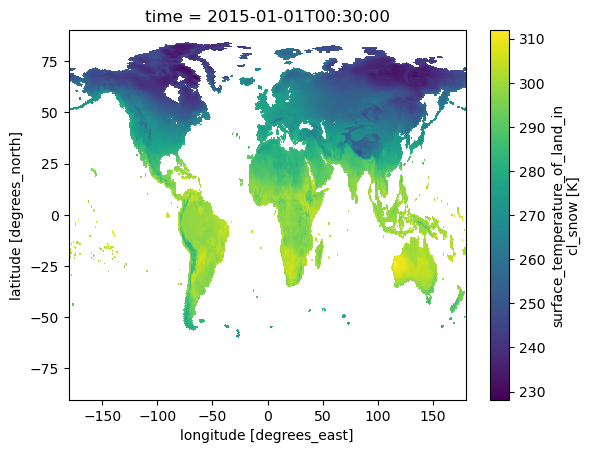

In [12]:
ds.TSURF.plot()

## Get the matchups

100 seconds for 19 points is pretty slow.

In [26]:
%%time
res = pc.matchup(plan, variables = ["TSURF", "LAI", "GWETROOT"])

CPU times: user 1min 30s, sys: 599 ms, total: 1min 30s
Wall time: 1min 41s


In [16]:
res[["lat", "lon", "time", "TSURF", "LAI", "GWETROOT"]].head()

,lat,lon,time,TSURF,LAI,GWETROOT
0,-17.432469,24.018931,2015-08-22 12:00:00,295.403625,0.478077,0.226221
1,-16.707673,14.478041,2016-03-24 12:00:00,298.818756,1.579376,0.379308
2,-83.839933,111.134906,2015-05-06 12:00:00,NaN,NaN,NaN
3,65.250200,-159.513009,2017-10-29 12:00:00,270.131592,0.728424,0.800289
4,28.315760,-1.839657,2016-12-14 12:00:00,285.662598,0.144973,0.129535


## Hourly 3D data

Now we will look at `M2T3NVASM`: hourly, gridded MERRA-2 dataset providing time-averaged 3D atmospheric variables (e.g., temperature, winds, humidity) on standard pressure levels.



In [36]:
df['altitude_index'] = 10

coord_spec = {
  "additional": {
    "altitude": {"source": "lev", "points": "altitude_index"},
  },
}
df.head()

,lat,lon,time,land,altitude_index
0,-17.432469,24.018931,2015-08-22 12:00:00,True,10
1,-16.707673,14.478041,2016-03-24 12:00:00,True,10
2,-83.839933,111.134906,2015-05-06 12:00:00,True,10
3,65.250200,-159.513009,2017-10-29 12:00:00,True,10
4,28.315760,-1.839657,2016-12-14 12:00:00,True,10


In [33]:
import point_collocation as pc
short_name="M2T3NVASM"
plan = pc.plan(
    df,
    data_source="earthaccess",
    source_kwargs={
        "short_name": short_name,
    }
)
plan.summary(n=2)

Plan: 19 points → 19 unique granule(s)
  Points with 0 matches : 0
  Points with >1 matches: 0
  Time buffer: 0 days 00:00:00

First 2 point(s):
  [0] lat=-17.4325, lon=24.0189, time=2015-08-22 12:00:00: 1 match(es)
    → https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2T3NVASM.5.12.4/2015/08/MERRA2_400.tavg3_3d_asm_Nv.20150822.nc4
  [1] lat=-16.7077, lon=14.4780, time=2016-03-24 12:00:00: 1 match(es)
    → https://data.gesdisc.earthdata.nasa.gov/data/MERRA2/M2T3NVASM.5.12.4/2016/03/MERRA2_400.tavg3_3d_asm_Nv.20160324.nc4


In [34]:
ds = plan.open_dataset(0, coord_spec=coord_spec)
ds

open_method: {'xarray_open': 'dataset', 'open_kwargs': {'chunks': {}, 'engine': 'h5netcdf', 'decode_timedelta': False}, 'coords': 'auto', 'set_coords': True, 'dim_renames': None, 'auto_align_phony_dims': None, 'merge': None}
Geolocation auto detected with cf_xarray: ('lon', 'lat') — lon dims=('lon',), lat dims=('lat',); time dim='time' (8 step(s))
Points columns used: y='lat', x='lon', time='time'


<xarray.Dataset> Size: 7GB
Dimensions:  (time: 8, lev: 72, lat: 361, lon: 576)
Coordinates:
  * time     (time) datetime64[ns] 64B 2015-01-06T01:30:00 ... 2015-01-06T22:...
  * lev      (lev) float64 576B 1.0 2.0 3.0 4.0 5.0 ... 68.0 69.0 70.0 71.0 72.0
  * lat      (lat) float64 3kB -90.0 -89.5 -89.0 -88.5 ... 88.5 89.0 89.5 90.0
  * lon      (lon) float64 5kB -180.0 -179.4 -178.8 -178.1 ... 178.1 178.8 179.4
Data variables: (12/17)
    CLOUD    (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    DELP     (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    EPV      (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    H        (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    O3       (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    OMEGA    (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    ...       ...
    QV       (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    RH       (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    SLP      (time, lat, lon) float32 7MB dask.array<chunksize=(1, 91, 144), meta=np.ndarray>
    T        (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    U        (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
    V        (time, lev, lat, lon) float32 479MB dask.array<chunksize=(1, 1, 91, 144), meta=np.ndarray>
Attributes: (12/30)
    History:                           Original file generated: Thu Mar 12 13...
    Comment:                           GMAO filename: d5124_m2_jan10.tavg3_3d...
    Filename:                          MERRA2_400.tavg3_3d_asm_Nv.20150106.nc4
    Conventions:                       CF-1
    Institution:                       NASA Global Modeling and Assimilation ...
    References:                        http://gmao.gsfc.nasa.gov
    ...                                ...
    Contact:                           http://gmao.gsfc.nasa.gov
    identifier_product_doi:            10.5067/SUOQESM06LPK
    RangeBeginningDate:                2015-01-06
    RangeBeginningTime:                00:00:00.000000
    RangeEndingDate:                   2015-01-06
    RangeEndingTime:                   23:59:59.000000

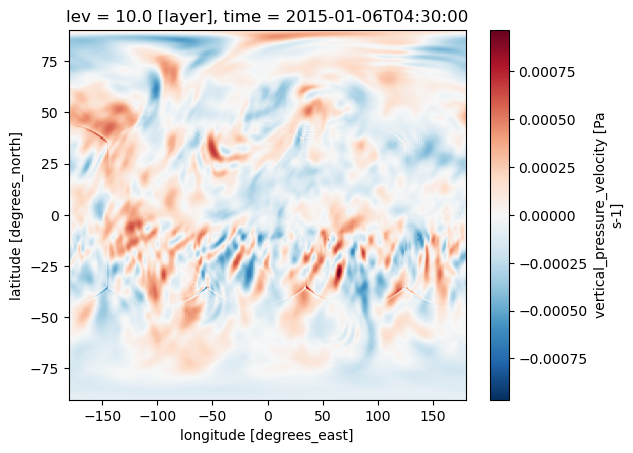

In [41]:
ds.OMEGA.sel(lev=10).isel(time=1).plot()

### Get the matchups

They with be 3D. `OMEGA` is vertical velocity. We will get for lev=10 (altitude_index in our dataframe).

In [37]:
%%time
res = pc.matchup(plan, variables = ["OMEGA"], coord_spec=coord_spec)

CPU times: user 17.6 s, sys: 2.42 s, total: 20 s
Wall time: 45.7 s


In [38]:
res[['lat', 'lon', 'time', 'altitude_index', 'OMEGA']].head()

,lat,lon,time,altitude_index,OMEGA
0,-17.432469,24.018931,2015-08-22 12:00:00,10,0.000063
1,-16.707673,14.478041,2016-03-24 12:00:00,10,-0.000089
2,-83.839933,111.134906,2015-05-06 12:00:00,10,-0.000008
3,65.250200,-159.513009,2017-10-29 12:00:00,10,0.000066
4,28.315760,-1.839657,2016-12-14 12:00:00,10,0.000146
